# Task
Analyze the Mall Customer dataset ("Mall_Customers.csv") to cluster customers based on income and spending score using K-Means clustering. Determine the optimal number of clusters, visualize the clusters, and analyze the average spending per cluster. Optionally, try other clustering algorithms like DBSCAN.

## Data loading

### Subtask:
Load the Mall Customer dataset into a pandas DataFrame.


**Reasoning**:
Import pandas and load the dataset into a DataFrame, then display the head to verify the data loading.



In [1]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data exploration and preparation

### Subtask:
Explore the dataset to understand its structure and identify potential issues. Select the relevant features (Income and Spending Score) for clustering.


**Reasoning**:
Print the concise summary and descriptive statistics of the DataFrame and select the relevant columns for clustering.



In [2]:
df.info()
display(df.describe())
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
display(X.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Data scaling

### Subtask:
Scale the selected features to ensure they have similar ranges, which is important for distance-based clustering algorithms like K-Means.


**Reasoning**:
Scale the selected features using StandardScaler for K-Means clustering.



In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
display(X_scaled[:5])

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## Optimal cluster determination

### Subtask:
Use a method like the Elbow Method to determine the optimal number of clusters for K-Means.


**Reasoning**:
Implement the Elbow Method to find the optimal number of clusters by calculating inertia for a range of cluster numbers and plotting the results.



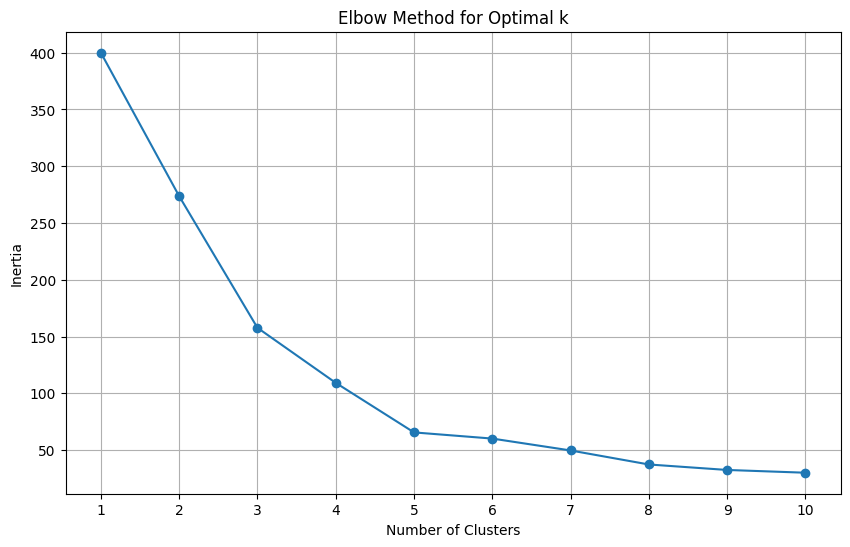

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## K-means clustering

### Subtask:
Apply the K-Means algorithm with the optimal number of clusters to segment the customers.


**Reasoning**:
Apply the KMeans algorithm with 5 clusters (visually determined as optimal from the Elbow plot) to segment the customers, get the cluster labels, and add them to the original dataframe.



In [5]:
kmeans = KMeans(n_clusters=5, n_init='auto', random_state=42)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Visualization

### Subtask:
Visualize the clusters using a 2D scatter plot to see how the customer segments are grouped based on Income and Spending Score.


**Reasoning**:
Visualize the clusters using a scatter plot to see how the customer segments are grouped based on Income and Spending Score as requested in the instructions.



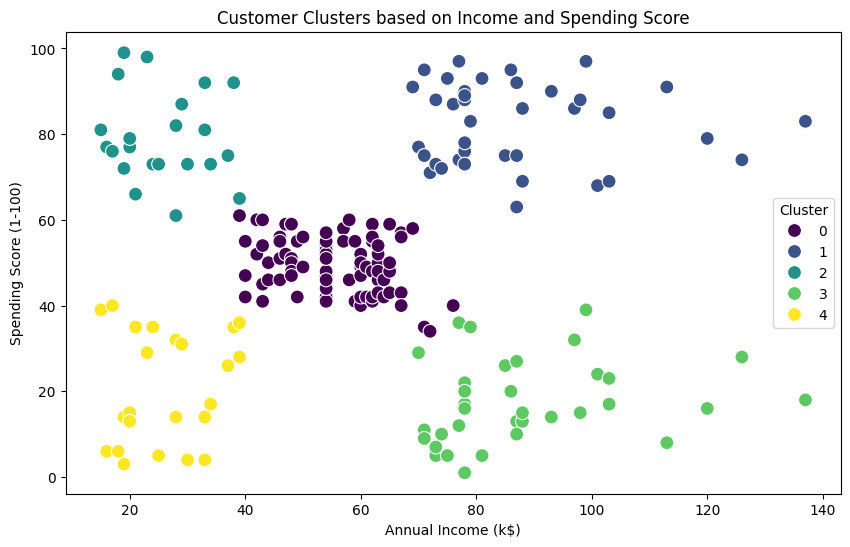

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=100)
plt.title('Customer Clusters based on Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

## Analyze average spending per cluster (bonus)

### Subtask:
Calculate and analyze the average spending score for each cluster to understand the characteristics of each customer segment.


**Reasoning**:
Calculate the average spending score for each cluster and display the results.



In [7]:
average_spending_by_cluster = df.groupby('Cluster')['Spending Score (1-100)'].mean()
display(average_spending_by_cluster)

,Spending Score (1-100)
Cluster,
0,49.518519
1,82.128205
2,79.363636
3,17.114286
4,20.913043


## Bonus: try different clustering algorithms (e.g., dbscan)

### Subtask:
Apply DBSCAN or other clustering algorithms to compare the results with K-Means.


**Reasoning**:
Import DBSCAN, instantiate it, fit it to the scaled data, add the cluster labels to the DataFrame, and display the head and unique values of the new cluster column.



In [8]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X_scaled)
df['DBSCAN_Cluster'] = dbscan.labels_
display(df.head())
display(df['DBSCAN_Cluster'].value_counts())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN_Cluster
0,1,Male,19,15,39,4,0
1,2,Male,21,15,81,2,0
2,3,Female,20,16,6,4,0
3,4,Female,23,16,77,2,0
4,5,Female,31,17,40,4,0


,count
DBSCAN_Cluster,
0,157
1,35
-1,8


## Summary:

### Data Analysis Key Findings

*   The dataset contains 200 entries with no missing values.
*   The Elbow Method suggests that 5 is the optimal number of clusters for K-Means based on the inertia plot.
*   K-Means clustering with 5 clusters successfully segmented the customers based on their annual income and spending score.
*   The average spending scores vary significantly across the clusters, indicating distinct spending behaviors:
    *   Clusters 1 and 2 have the highest average spending scores (82.13 and 79.36 respectively).
    *   Clusters 3 and 4 have the lowest average spending scores (17.11 and 20.91 respectively).
    *   Cluster 0 has a moderate average spending score (49.52).
*   DBSCAN clustering, with the chosen parameters, identified two main clusters and classified 8 customers as noise. This resulted in a different clustering structure compared to K-Means.

### Insights or Next Steps

*   The identified customer clusters can be used to tailor marketing strategies and promotions to specific segments (e.g., target high-spending clusters with loyalty programs).
*   Further analysis could involve examining the demographic characteristics (Gender, Age) within each cluster to gain deeper insights into the customer segments.
